# Robotics, Vision & Control 3e: for Python
## Chapter 5: Navigation

Copyright (c) 2021- Peter Corke

In [1]:
try:
    import google.colab
    print('Running on CoLab')
    #!pip install roboticstoolbox-python>=1.0.2
    !pip install git+https://github.com/petercorke/robotics-toolbox-python@future
    !pip install spatialmath-python>=1.1.5
    !pip install bdsim
    !pip install --no-deps rvc3python
    COLAB = True
except ModuleNotFoundError:
    COLAB = False

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last_expr_or_assign"
from IPython.display import HTML

%matplotlib widget 

import matplotlib.pyplot as plt

# add RTB examples folder to the path
import sys, os.path
import RVC3 as rvc
sys.path.append(os.path.join(rvc.__path__[0], 'models'))

# helper function to run bdsim in a subprocess and transfer results using a pickle file
import pickle
def run_shell(tool, **params):
    global out
    pyfile = os.path.join(rvc.__path__[0], "models", tool+".py")
    cmd = f"python {pyfile} -H +a -o"
    for key, value in params.items():
        cmd += f' --global "{key}={value}"'
    print(cmd)
    os.system(cmd)
    with open("bd.out", "rb") as f:
        out = pickle.load(f)
        
# ------ standard imports ------ #
import numpy as np
import math
from math import pi
np.set_printoptions(
    linewidth=120, formatter={
        'float': lambda x: f"{0:8.4g}" if abs(x) < 1e-10 else f"{x:8.4g}"})
np.random.seed(0)
from spatialmath import *
from spatialmath.base import *
from roboticstoolbox import *


# 5.1 Introduction to Reactive Navigation


## 5.1.1 Braitenberg Vehicles


In [2]:
def sensorfield(x, y):
  xc, yc = (60, 90)
  return 200 / ((x - xc) ** 2 + (y - yc) ** 2 + 200)

<div style="background-color:red">
<span style="background-color:red; font-size:20pt">NOTE</span>

There are issues in running bdsim from inside Jupyter.  We have two options, disable all graphics (which is a bit dull) or run bdsim from a subprocess with its own popout windows.

For Colab we can only do the first option.  

Otherwise, we use the wrapper function `run_shell()` defined in the first cell to spawn a new Python instance to run the block diagram which will pop up new windows on your screen to display a simple animation showing the vehicle's motion in the plane.  This makes it a bit harder to get parameters and data between Jupyter and the `bdsim` simulation, so:
* parameter values are passed to `bdsim` as `--global` command line options.
* the `-o` command line option to `bdsim` causes it to write results as a pickle file, which are then imported back into Jupyter.</div>

In [3]:
if COLAB:
  %run -m braitenberg -H -g  # no graphics
else:
  run_shell("braitenberg")

python c:\Users\MateoAlmeida\Desktop\10mo\robotic\localRep\roboticDev\Lib\site-packages\RVC3\models\braitenberg.py -H +a -o


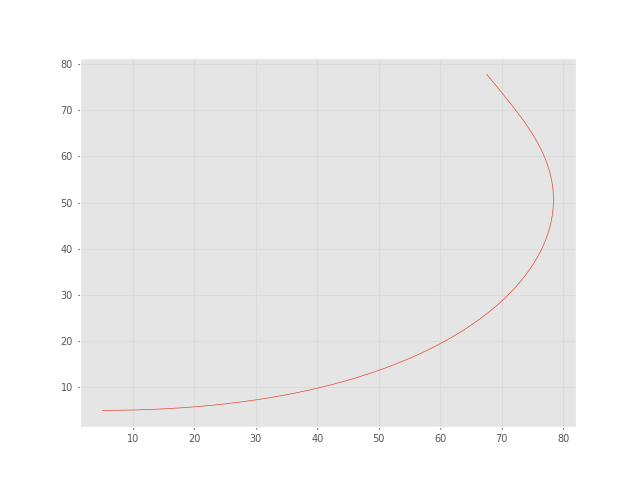

In [4]:
plt.plot(out.x[:,0], out.x[:,1]);

## 5.1.2 Simple Automata


In [5]:
house = rtb_load_matfile("data/house.mat");

In [6]:
floorplan = house["floorplan"];
floorplan.shape

(397, 596)

In [7]:
places = house["places"];
places.keys()

dict_keys(['kitchen', 'garage', 'br1', 'br2', 'br3', 'nook', 'mudroom', 'patio', 'study', 'garden', 'driveway', 'living'])

In [8]:
places.br3

array([50, 50], dtype=uint8)

In [9]:
bug = Bug2(occgrid=floorplan);

In [10]:
bug.plot();

In [11]:
bug.run(start=places.br3, goal=places.br1, speed=0.5);
bug.plot() 

<Axes: xlabel='x', ylabel='y'>

In [12]:
# bug.run(start=places.br3, goal=places.kitchen, animate=True);  # wont work in Jupyter

path = bug.run(start=places.br3, goal=places.kitchen);  # compute the path
path.shape

(1307, 2)

In [13]:
bug.plot(path);  # then overlay it on the map

# 5.2 Introduction to Map-Based Navigation


# 5.3 Planning with a Graph-Based Map


In [14]:
data = rtb_load_jsonfile("data/queensland.json");

In [15]:
for name, info in data["places"].items():
  plot_point(info["utm"], text=name)

In [16]:
data["routes"][0]

{'start': 'Camooweal', 'end': 'Mount Isa', 'distance': 188, 'speed': 100}

In [17]:
import pgraph
g = pgraph.UGraph()  # create empty undirected graph
for name, info in data["places"].items():
  g.add_vertex(name=name, coord=info["utm"])  # add a place
for route in data["routes"]:
  g.add_edge(route["start"], route["end"], 
             cost=route["distance"])  # add a route

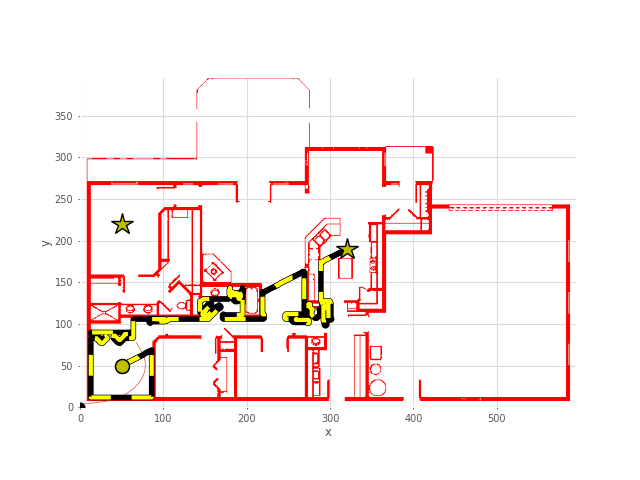

In [18]:
g.plot()

In [19]:
g.n
g.ne

29

In [20]:
g["Brisbane"]

UVertex[Brisbane, coord=(1096, 6947)]

In [21]:
g["Brisbane"].neighbors() 

[UVertex[Rockhampton, coord=(858.9, 7410)], UVertex[Roma, coord=(677.7, 7060)]]

In [22]:
g["Brisbane"].degree

2

In [23]:
g.average_degree()

2.9

In [24]:
g.nc

1

In [25]:
edges = g["Brisbane"].edges()

[Edge{[Rockhampton] -- [Brisbane], cost=682},
 Edge{[Brisbane] -- [Roma], cost=482}]

In [26]:
edges[0].endpoints

[UVertex[Rockhampton, coord=(858.9, 7410)],
 UVertex[Brisbane, coord=(1096, 6947)]]

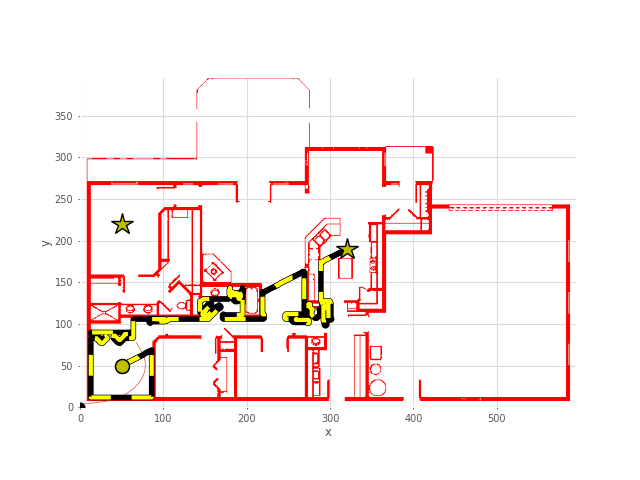

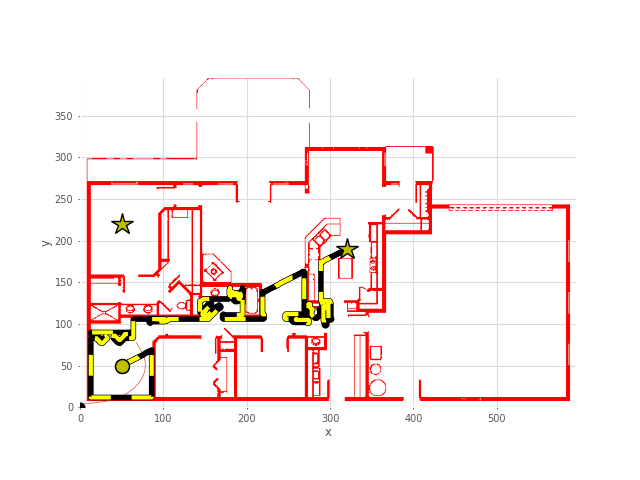

In [27]:
path, length = g.path_BFS("Hughenden", "Brisbane")
length
", ".join([p.name for p in path])
ax = g.plot(block=None)
g.highlight_path(path)


In [28]:
path, length, parents = g.path_UCS("Hughenden", "Brisbane")
length
", ".join([p.name for p in path])

'Hughenden, Barcaldine, Blackall, Charleville, Roma, Brisbane'

In [29]:
parents["Winton"]

'Hughenden'

In [30]:
tree = pgraph.DGraph.Dict(parents);

In [31]:
tree.showgraph()

In [32]:
g.path_UCS("Hughenden", "Brisbane", verbose=True)


FRONTIER: Hughenden(0)
EXPLORED: 
   expand Hughenden
      add Cloncurry to the frontier
      add Charters Towers to the frontier
      add Barcaldine to the frontier
      add Winton to the frontier
     move Hughenden to the explored list

FRONTIER: Cloncurry(401), Charters Towers(248), Barcaldine(500), Winton(216)
EXPLORED: Hughenden
   expand Winton
      add Longreach to the frontier
      add Boulia to the frontier
      add Windorah to the frontier
     move Winton to the explored list

FRONTIER: Cloncurry(401), Charters Towers(248), Barcaldine(500), Longreach(396), Boulia(579), Windorah(703)
EXPLORED: Hughenden, Winton
   expand Charters Towers
      add Townsville to the frontier
     move Charters Towers to the explored list

FRONTIER: Cloncurry(401), Barcaldine(500), Longreach(396), Boulia(579), Windorah(703), Townsville(383)
EXPLORED: Hughenden, Winton, Charters Towers
   expand Townsville
      add Mackay to the frontier
     move Townsville to the explored list

FRONTI

([UVertex[Hughenden, coord=(208.6, 7692)],
  UVertex[Barcaldine, coord=(325.8, 7394)],
  UVertex[Blackall, coord=(344.5, 7299)],
  UVertex[Charleville, coord=(424.7, 7080)],
  UVertex[Roma, coord=(677.7, 7060)],
  UVertex[Brisbane, coord=(1096, 6947)]],
 1659,
 {'Cloncurry': 'Hughenden',
  'Charters Towers': 'Hughenden',
  'Barcaldine': 'Hughenden',
  'Winton': 'Hughenden',
  'Longreach': 'Winton',
  'Boulia': 'Winton',
  'Windorah': 'Winton',
  'Townsville': 'Charters Towers',
  'Mackay': 'Townsville',
  'Mount Isa': 'Cloncurry',
  'Blackall': 'Barcaldine',
  'Emerald': 'Barcaldine',
  'Camooweal': 'Mount Isa',
  'Bedourie': 'Boulia',
  'Charleville': 'Blackall',
  'Birdsville': 'Bedourie',
  'Rockhampton': 'Emerald',
  'Roma': 'Charleville',
  'Brisbane': 'Roma'})

In [33]:
g["Bedourie"].edgeto(g["Birdsville"]).cost

193

In [34]:
path, length, parents = g.path_Astar("Hughenden", "Brisbane", summary=True)
length
", ".join([p.name for p in path])

12 vertices explored, 3 remaining on the frontier


'Hughenden, Barcaldine, Blackall, Charleville, Roma, Brisbane'

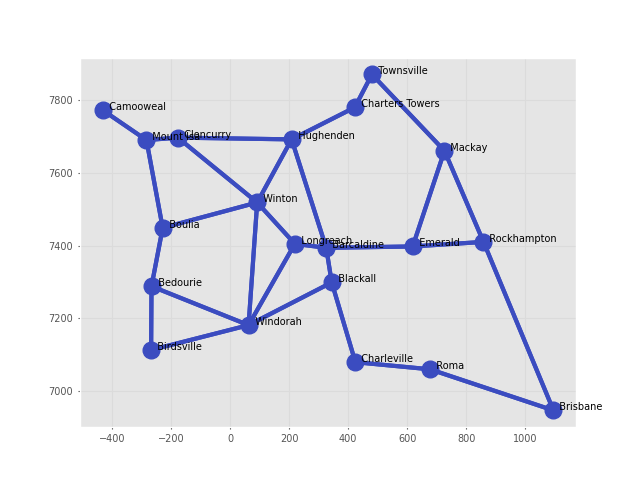

In [35]:
# find the unique vertex names
visited = set(list(parents.keys()) + list(parents.values()));
plt.clf()
g.plot(block=None)
# g.highlight_vertex(visited, color="yellow")

In [36]:
g.path_Astar("Hughenden", "Brisbane", verbose=True)


FRONTIER: Hughenden(0)
EXPLORED: 
   expand Hughenden
      add Cloncurry to the frontier
      add Charters Towers to the frontier
      add Barcaldine to the frontier
      add Winton to the frontier
     move Hughenden to the explored list

FRONTIER: Cloncurry(1878), Charters Towers(1319), Barcaldine(1390), Winton(1371)
EXPLORED: Hughenden
   expand Charters Towers
      add Townsville to the frontier
     move Charters Towers to the explored list

FRONTIER: Cloncurry(1878), Barcaldine(1390), Winton(1371), Townsville(1493)
EXPLORED: Hughenden, Charters Towers
   expand Winton
      add Longreach to the frontier
      add Boulia to the frontier
      add Windorah to the frontier
     move Winton to the explored list

FRONTIER: Cloncurry(1878), Barcaldine(1390), Townsville(1493), Longreach(1385), Boulia(1995), Windorah(1762)
EXPLORED: Hughenden, Charters Towers, Winton
   expand Longreach
     move Longreach to the explored list

FRONTIER: Cloncurry(1878), Barcaldine(1390), Townsvill

([UVertex[Hughenden, coord=(208.6, 7692)],
  UVertex[Barcaldine, coord=(325.8, 7394)],
  UVertex[Blackall, coord=(344.5, 7299)],
  UVertex[Charleville, coord=(424.7, 7080)],
  UVertex[Roma, coord=(677.7, 7060)],
  UVertex[Brisbane, coord=(1096, 6947)]],
 1659,
 {'Cloncurry': 'Hughenden',
  'Charters Towers': 'Hughenden',
  'Barcaldine': 'Hughenden',
  'Winton': 'Hughenden',
  'Townsville': 'Charters Towers',
  'Longreach': 'Winton',
  'Boulia': 'Winton',
  'Windorah': 'Winton',
  'Blackall': 'Barcaldine',
  'Emerald': 'Barcaldine',
  'Charleville': 'Blackall',
  'Mackay': 'Townsville',
  'Rockhampton': 'Emerald',
  'Roma': 'Charleville',
  'Brisbane': 'Roma'})

## 5.3.1 Minimum-Time Path Planning


In [37]:
g = pgraph.UGraph()
for name, info in data["places"].items():
  g.add_vertex(name=name, coord=info["utm"])
for route in data["routes"]:
  g.add_edge(route["start"], route["end"], 
             cost=route["distance"] / route["speed"])

In [38]:
g.heuristic = lambda x: np.linalg.norm(x) / 100

In [39]:
path, time, _ = g.path_Astar("Hughenden", "Brisbane")
time
", ".join([p.name for p in path])

'Hughenden, Winton, Longreach, Barcaldine, Blackall, Charleville, Roma, Brisbane'

# 5.4 Planning with an Occupancy-Grid Map


## 5.4.1 Distance Transform


In [40]:
map = np.zeros((100, 100));

In [41]:
map[40:50, 20:80] = 1;  # set to occupied

In [42]:
map.ravel()[np.random.choice(map.size, 100, replace=False)] = 1;

In [43]:
simplegrid = np.zeros((6, 6));
simplegrid[2:5, 3:5] = 1
simplegrid[3:5, 2] = 1

In [44]:
dx = DistanceTransformPlanner(occgrid=simplegrid);

In [45]:
dx.plan(goal=(1, 1))

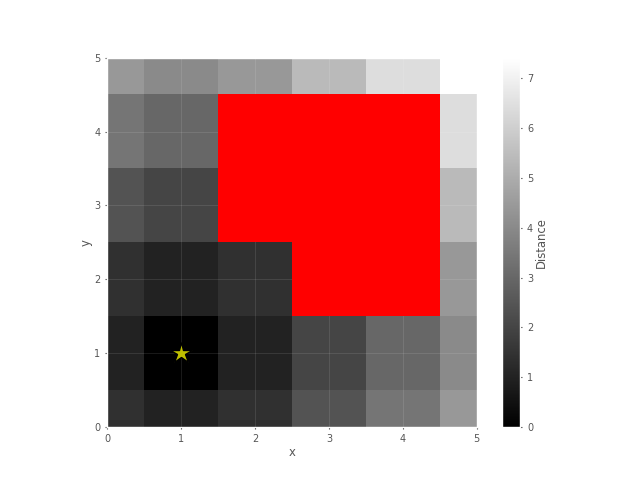

In [46]:
fig, ax = plt.subplots()
dx.plot(labelvalues=True, ax=ax, block=False)
plt.show()

In [47]:
dx = DistanceTransformPlanner(occgrid=simplegrid, distance="manhattan");
dx.plan(goal=(1, 1))
#dx.plot(labelvalues=True);

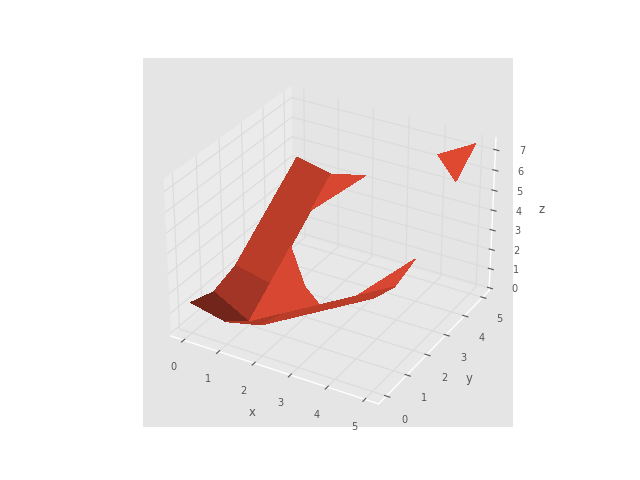

In [48]:
dx.plot_3d();

In [49]:
path = dx.query(start=(5, 4))

array([[5, 4],
       [5, 3],
       [5, 2],
       [4, 1],
       [3, 1],
       [2, 1],
       [1, 1]])

In [50]:
#dx.plot(path);

In [51]:
 #dx.query(start=(5, 4), animate=True);
# won't work in Jupyter

In [52]:
house = rtb_load_matfile("data/house.mat");
floorplan = house["floorplan"];
places = house["places"];

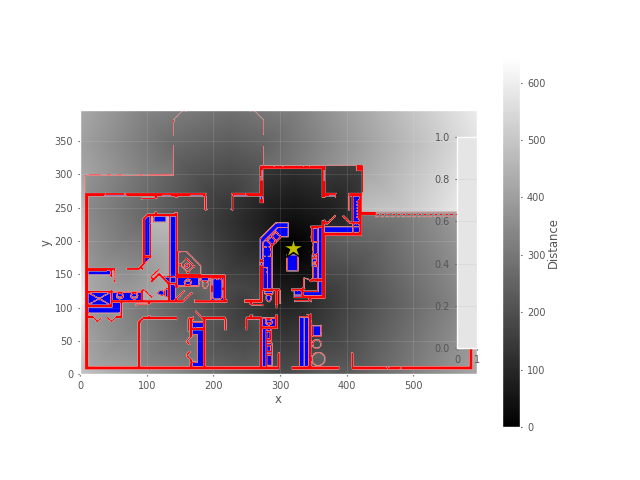

In [53]:
fig, ax = plt.subplots()
dx = DistanceTransformPlanner(occgrid=floorplan);
dx.plan(goal=places.kitchen)
dx.plot(colorbar = True, labelvalues=True , cax=ax.inset_axes([0.95, 0.1, 0.05, 0.8]) );

In [54]:
path = dx.query(start=places.br3);
path.shape

(338, 2)

In [55]:
#dx.plot(path, colorbar = False, ax = ax, cax= None, mappable=False );

In [56]:
dx.plan(places.kitchen, summary=True);

571 iterations, 9925 unreachable cells


In [57]:
# dx.plan(places.kitchen, animate=True);
# won't work in Jupyter

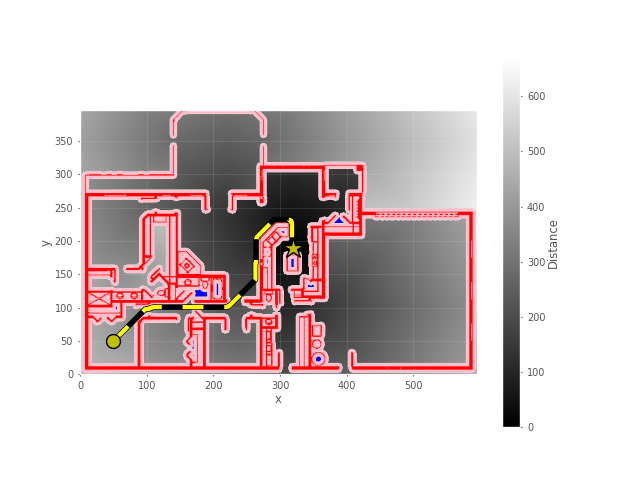

In [58]:
dx = DistanceTransformPlanner(occgrid=floorplan, inflate=5)
dx.plan(places.kitchen)
p = dx.query(places.br3)

fig, ax = plt.subplots()
dx.plot(p, ax=ax)
plt.show()

In [59]:
dx = DistanceTransformPlanner(occgrid=floorplan, inflate=5);
dx.plan(places.kitchen);
p = dx.query(places.br3);
dx.plot(p);

## 5.4.2 D*


In [60]:
dstar = DstarPlanner(occgrid=floorplan);

In [61]:
c = dstar.costmap;

In [62]:
dstar.plan(goal=places.kitchen);

In [63]:
nexpand0 = dstar.nexpand

359764

In [64]:
path = dstar.query(start=places.br3);

In [65]:
def sensorfunc(pos):
   if pos[0] == 300:  # near the door?
       changes = []
       for x in range(300, 325):
           for y in range(115,125):
               changes.append((x, y, np.inf))
       return changes

In [66]:
dstar.query(start=places.br3, sensor=sensorfunc);

propagate
propagate


In [67]:
dstar.nexpand - nexpand0

42792

# 5.5 Planning with Roadmaps


In [68]:
occgrid = floorplan.copy();

In [69]:
occgrid[0, :] = 1
occgrid[-1, :] = 1
occgrid[:, 0] = 1
occgrid[:, -1] = 1

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


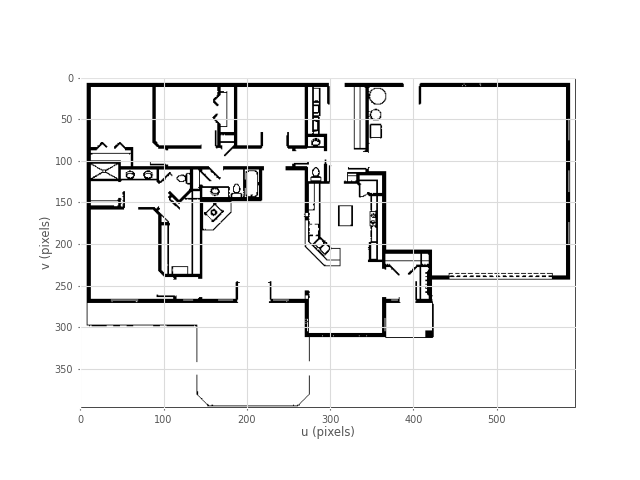

In [70]:
from machinevisiontoolbox import Image

freespace = Image(occgrid == 0)
freespace.disp();

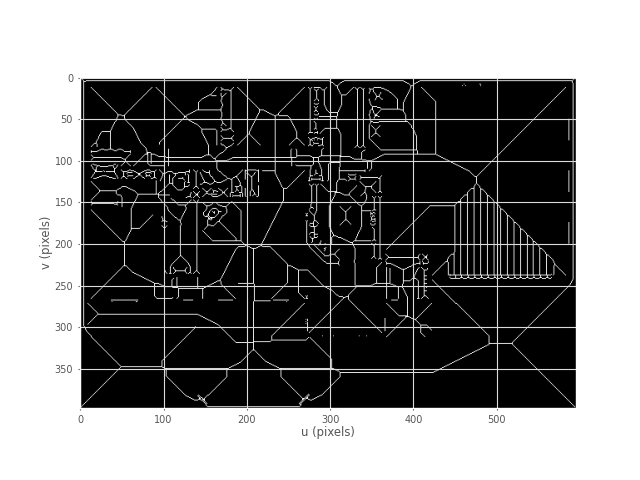

In [71]:
skeleton = freespace.thin().disp();

### Excurse 5.8: Voronoi Tessellation

In [72]:
sites = np.random.uniform(size=(2,9));
from scipy.spatial import Voronoi

vor = Voronoi(sites.T);

from scipy.spatial import voronoi_plot_2d

ax = plt.gca()
ax.plot(sites[0,:], sites[1,:], "k*", markersize=10)
voronoi_plot_2d(vor, ax=ax, show_points=False)
ax.set_aspect('equal')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)


(0.0, 1.0)

In [73]:
prm = PRMPlanner(occgrid=floorplan, seed=0);

In [74]:
prm.plan(npoints=50)

In [75]:
prm

PRMPlanner: 
  BinaryOccupancyGrid: 596 x 397, cell size=1, x = [0.0, 595.0], y = [0.0, 396.0], 8.8% occupied
  UGraph: 50 vertices, 222 edges, 12 components

plotted background


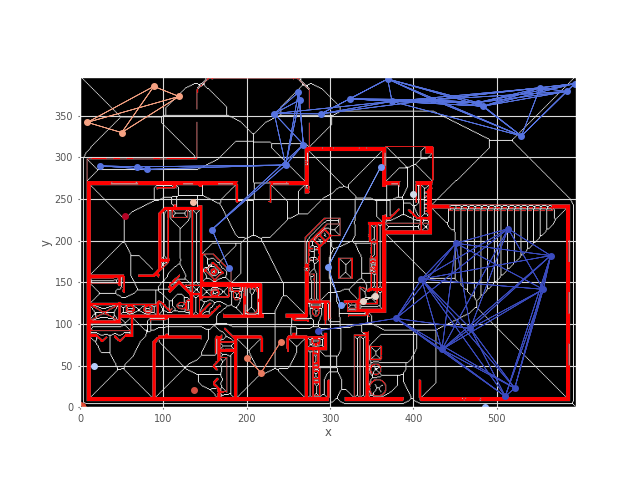

plotted roadmap


In [76]:
prm.plot();

plotted background


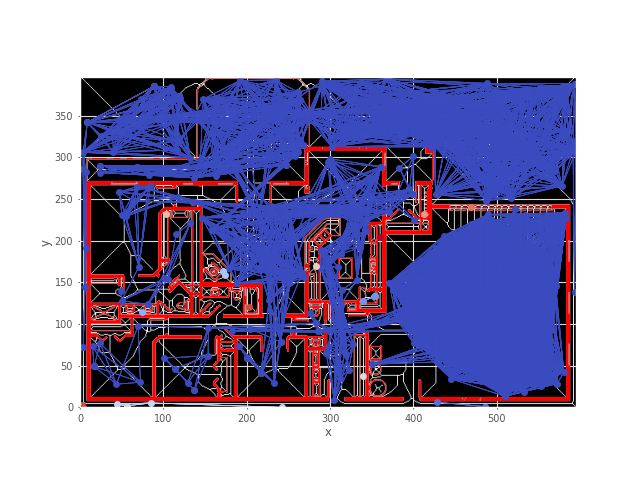

plotted roadmap


PRMPlanner: 
  BinaryOccupancyGrid: 596 x 397, cell size=1, x = [0.0, 595.0], y = [0.0, 396.0], 8.8% occupied
  UGraph: 300 vertices, 10000 edges, 13 components

In [77]:
prm.plan(npoints=300)
prm.plot();
prm

In [78]:
np.random.rand(5)  # seeded by NumPy (not repeatable)
np.random.seed(42)
np.random.rand(5)  # with seed of 42
np.random.seed(42)
np.random.rand(5)  # with seed of 42

array([  0.3745,   0.9507,    0.732,   0.5987,    0.156])

plotted background


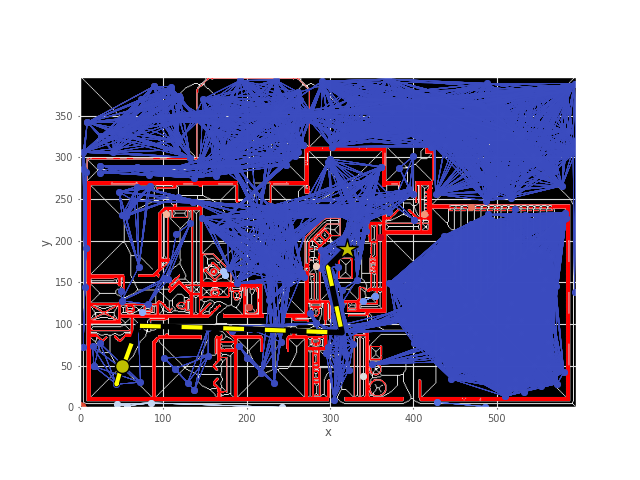

plotted roadmap


In [79]:
path = prm.query(start=places.br3, goal=places.kitchen);
prm.plot(path)

In [80]:
path = prm.query(start=places.br2, goal=places.kitchen);
path.shape

(8, 2)

# 5.6 Planning Driveable Paths


In [81]:
qs = (0, 0, pi/2);
qg = (1, 0, pi/2);

## 5.6.1 Dubins Path Planner


In [82]:
dubins = DubinsPlanner(curvature=1)

DubinsPlanner: 
  curvature=1, stepsize=0.1

In [83]:
path, status = dubins.query(qs, qg)
path.shape

(74, 3)

In [84]:
dubins.plot(path);

In [85]:
status

DubinsStatus(segments=['L', 'S', 'L'], length=7.283185307179586, seglengths=[4.71238898038469, 1.0, 1.5707963267948966])

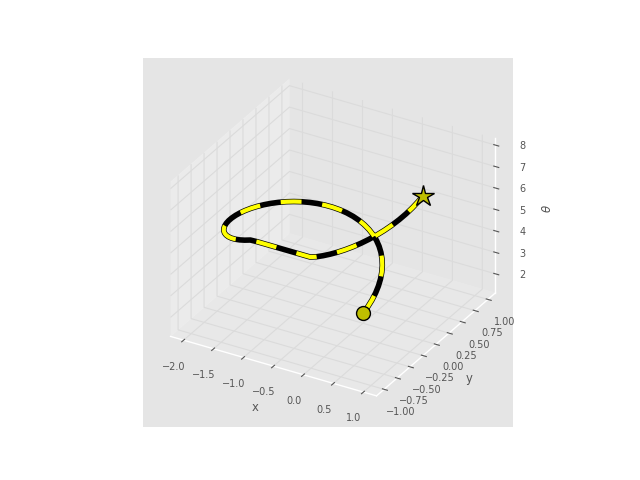

In [86]:
dubins.plot(path, configspace=True);

## 5.6.2 Reeds-Shepp Path Planner


In [87]:
rs = ReedsSheppPlanner(curvature=1)
path, status = rs.query(qs, qg)
path.shape
status

ReedsSheppStatus(segments=['R', 'L', 'R'], length=6.283185307179586, seglengths=[4.459708725242611, -0.5053605102841573, 1.3181160716528177], direction=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

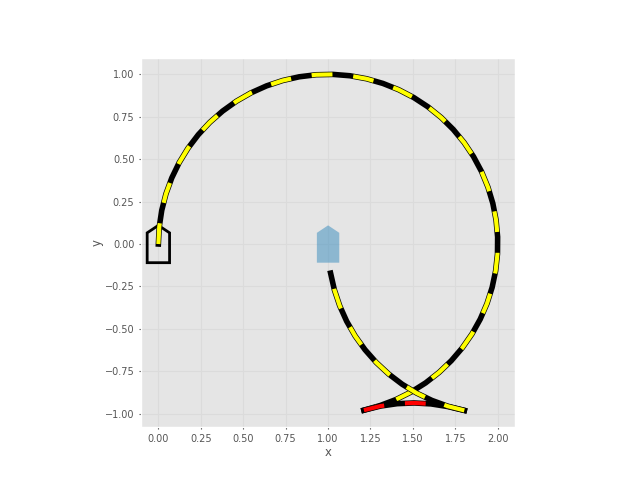

In [88]:
rs.plot(path, direction=status.direction);

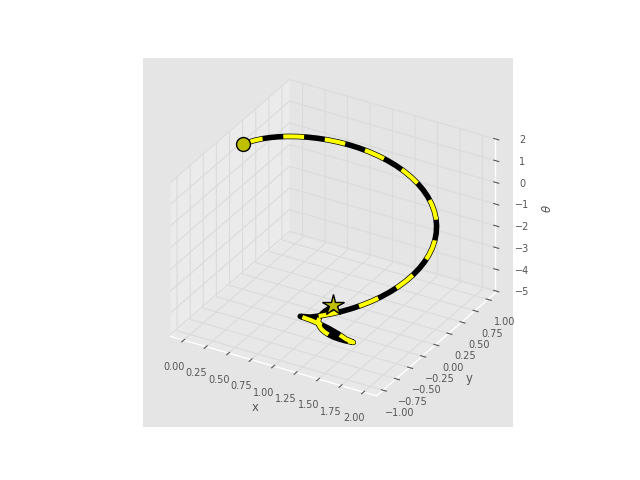

In [89]:
rs.plot(path, configspace=True);

## 5.6.3 Lattice Planner


4 vertices and 3 edges created


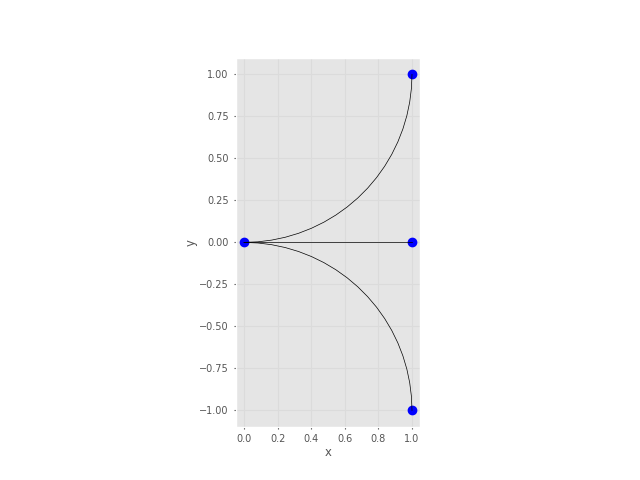

In [90]:
lp = LatticePlanner();
lp.plan(iterations=1, summary=True)
lp.plot()

In [91]:
lp.plan(iterations=2, summary=True)
lp.plot()

13 vertices and 12 edges created


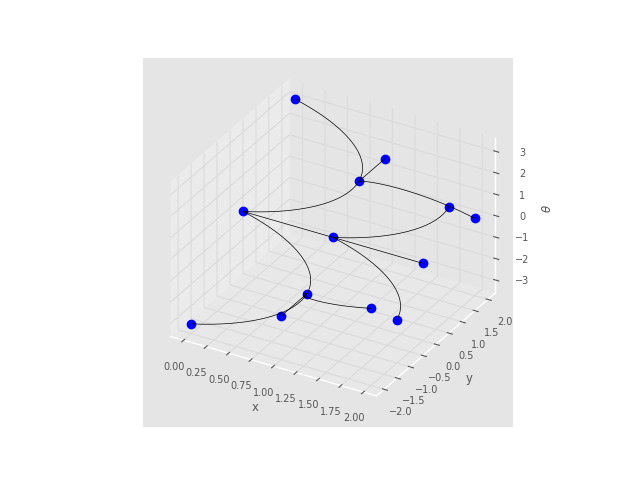

In [92]:
lp.plot(configspace=True)

780 vertices and 1698 edges created


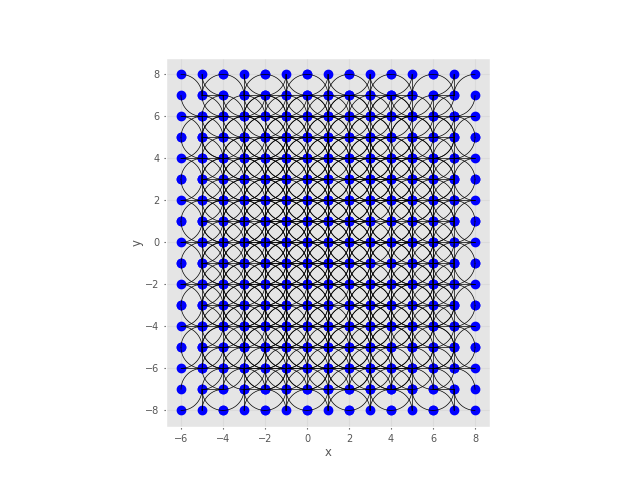

In [93]:
lp.plan(iterations=8, summary=True)
lp.plot()

In [94]:
path, status = lp.query(qs, qg);
path.shape

(6, 3)

In [95]:
lp.plot(path)

In [96]:
status

LatticeStatus(cost=7.283185307179586, segments=['L', 'L', 'L', 'S', 'L'], edges=[Edge{[0SRRRS] -- [0SLSLLR], cost=1.571}, Edge{[0SLSLLR] -- [0LLSLS], cost=1.571}, Edge{[0LLSLS] -- [0LLSLSL], cost=1.571}, Edge{[0LLSLSL] -- [0LLLSL], cost=1}, Edge{[0LLLSL] -- [0SSRRRS], cost=1.571}])

In [97]:
lattice = LatticePlanner(costs=[1, 10, 1])  # S, L, R
lp.plan(iterations=8)
path, status = lp.query(qs, qg)

In [98]:
og = BinaryOccupancyGrid(workspace=[-5, 5, -5, 5], value=False)

BinaryOccupancyGrid: 11 x 11, cell size=1, x = [-5.0, 5.0], y = [-5.0, 5.0], 0.0% occupied

In [99]:
og.set([-2, 0, -2, -1], True)
og.set([2, 3, 0, 4], True)
og.set([0, 2, -2, -2], True)

In [100]:
lattice = LatticePlanner(occgrid=og)
lattice.plan(iterations=None)

iteration 1, frontier length 3
iteration 2, frontier length 3
iteration 3, frontier length 6
iteration 4, frontier length 15
iteration 5, frontier length 35
iteration 6, frontier length 52
iteration 7, frontier length 67
iteration 8, frontier length 86
iteration 9, frontier length 105
iteration 10, frontier length 111
iteration 11, frontier length 94
iteration 12, frontier length 82
iteration 13, frontier length 75
iteration 14, frontier length 79
iteration 15, frontier length 96
iteration 16, frontier length 126
iteration 17, frontier length 155
iteration 18, frontier length 147
iteration 19, frontier length 92
iteration 20, frontier length 39
iteration 21, frontier length 24
iteration 22, frontier length 13
iteration 23, frontier length 4
iteration 24, frontier length 2
finished after 25 iterations


In [101]:
path, status = lattice.query(qs, qg)
lattice.plot(path)

## 5.6.4 Curvature Polynomials


In [102]:
cpoly = CurvaturePolyPlanner()
path, status = cpoly.query(qs, qg)
status
cpoly.plot(path);

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 6.232212614899684e-07
        x: [ 3.059e+00  3.095e+00  2.234e+00 -4.865e+00  1.299e+00]
      nit: 41
      jac: [ 7.301e-03  8.170e-04 -1.304e-02 -3.601e-02  1.841e-01]
     nfev: 486
     njev: 81
 hess_inv: <5x5 LbfgsInvHessProduct with dtype=float64>


## 5.6.5 Planning in Configuration Space


In [103]:
map = PolygonMap(workspace=[0, 10]);
map.add([(5, 50), (5, 6), (6, 6), (6, 50)])
map.add([(5, 4), (5, -50), (6, -50), (6, 4)])

In [104]:
map.plot()

qs = (2, 8, -pi/2);
qg = (8, 2, -pi/2);

piano = VehicleIcon("piano", scale=3)
piano.plot(qs);
piano.plot(qg);

In [105]:
l, w = 3, 1.5;
vpolygon = Polygon2([(-l/2, w/2), (-l/2, -w/2),
                     (l/2, -w/2), (l/2, w/2)]);

In [106]:
q = (2, 4, 0);

In [107]:
map.iscollision(vpolygon.transformed(SE2(q)))

False

In [108]:
vehicle = Bicycle(steer_max=1, L=2, polygon=vpolygon);

In [109]:
vehicle.curvature_max

0.7787038623274511

In [110]:
rrt = RRTPlanner(map=map, vehicle=vehicle, npoints=50, showsamples=True, seed=0)

curvature 1.0


RRTPlanner: 

In [111]:
q = rrt.qrandom()
rrt.iscollision(q)

True

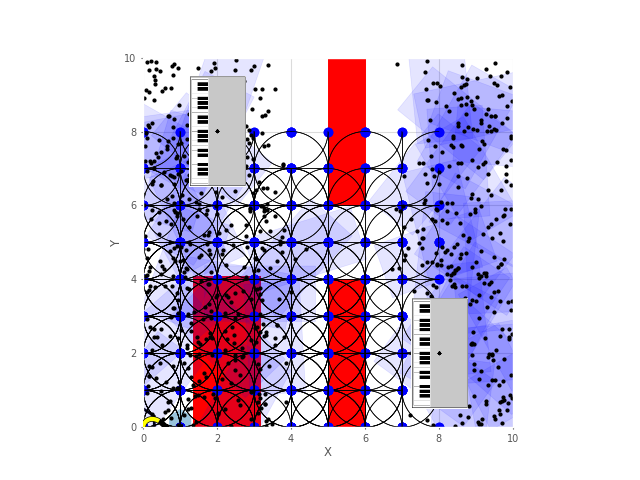

In [112]:
# rrt.plan(goal=qg, animate=True)
rrt.plan(goal=qg, animate=False)

In [113]:
path, status = rrt.query(start=qs);

[DVertex[#34, coord=(1.644, 7.95, -2.051)], DVertex[#25, coord=(1.52, 6.047, -2.131)], DVertex[#23, coord=(4.394, 4.813, 0.3043)], DVertex[#17, coord=(7.913, 4.707, 0.3379)], DVertex[#11, coord=(8.999, 4.479, -0.5868)], DVertex[#3, coord=(8.224, 4.8, -1.682)], DVertex[#0, coord=(8, 2, -1.571)]]


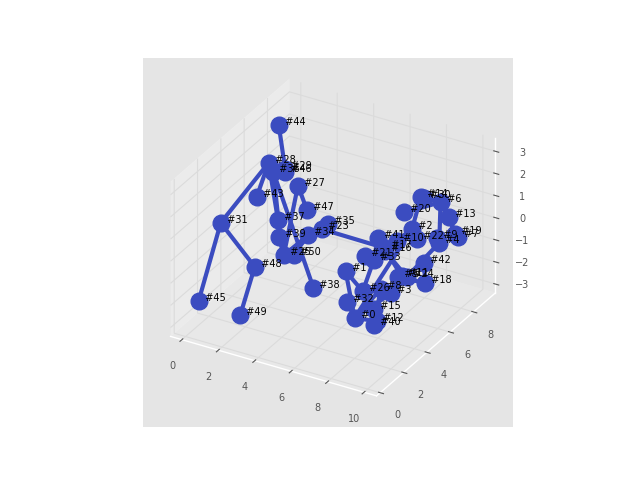

In [114]:
rrt.g.plot()

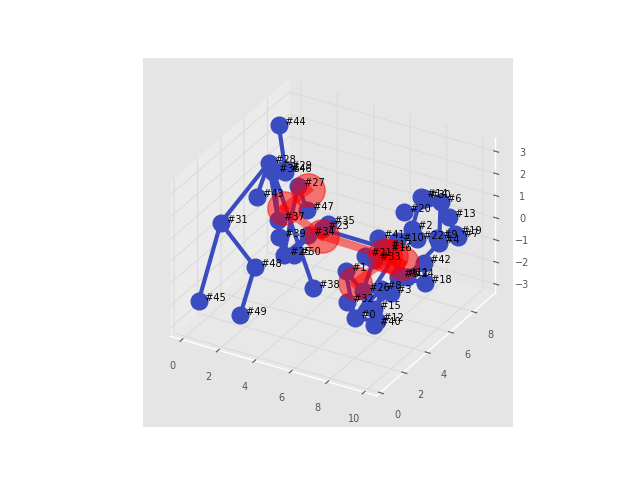

In [115]:
rrt.g.highlight_path(status.vertices, color="red")

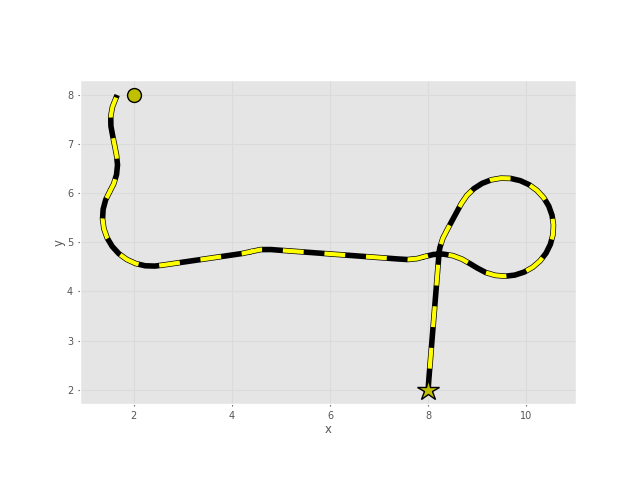

In [116]:
rrt.plot(path);

In [117]:
status.initial_d

0.5996466379914136

# 5.7 Advanced Topics


## 5.7.3 Converting between Graphs and Matrices


In [118]:
import pgraph
g = pgraph.UGraph()
for i in range(4):  # add 4 vertices
  g.add_vertex()
g[0].connect(g[1], cost=1);  # 0 -- 1
g[0].connect(g[3], cost=2);  # 0 -- 3
g[1].connect(g[2], cost=3);  # 1 -- 2
g.distance()

array([[       0,        1,        0,        2],
       [       1,        0,        3,        0],
       [       0,        3,        0,        0],
       [       2,        0,        0,        0]])